In [1]:
# %%
import rasterio
import rasterio.plot
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
tqdm.pandas()

import geopandas as gpd
import ee
import geemap
from shapely import wkt
import pandas as pd
import shapely 
from pyproj import Transformer
import geopandas as gpd


cloud_project = "hedgementation"

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)



*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
gdf_2024 = gpd.GeoDataFrame.from_file("../../gpkgs/haie_2024.gpkg", engine='pyogrio', use_arrow=True)



In [26]:
gdf_2024 = gdf_2024.to_crs(crs="EPSG:4326")

In [4]:
len(gdf_2024)

20529039

In [ ]:
gdf_2020 = gpd.GeoDataFrame.from_file(f"../../gpkgs/haie_2020.gpkg", engine='pyogrio', use_arrow=True)
gdf_2020 = gpd.GeoDataFrame(gdf_2020, crs="4326")

In [31]:
missing_hedgerows = gdf_2020[~gdf_2020["cleabs"].isin(gdf_2024["cleabs"])]

In [32]:
len(missing_hedgerows)

927865

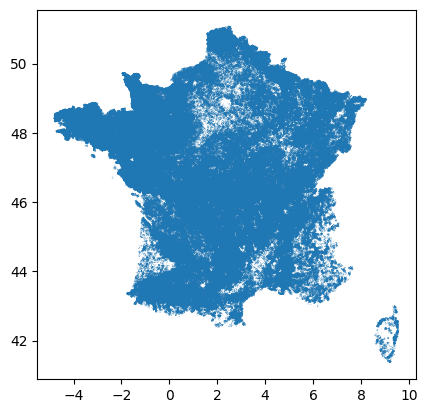

In [33]:
missing_hedgerows.plot()
plt.show()

In [35]:
joined = gdf_2020.merge(gdf_2024,on="cleabs",how="inner")[["cleabs", "geometry_x", "geometry_y"]]
joined = joined.rename({
    "geometry_x": "geometry_2020",
    "geometry_y": "geometry_2024"
},axis=1)
joined.columns


Index(['cleabs', 'geometry_2020', 'geometry_2024'], dtype='object')

In [14]:
print(f"Number of 2020 hedgerows: {len(gdf_2020)}")
print(f"Number of 2024 hedgerows: {len(gdf_2024)}")
print(f"Number of samples that share cleabs: {len(joined)}({int(100 * len(joined) / len(gdf_2024))}% of 2024, {int(100 * len(joined) / len(gdf_2020))}% of 2020)")

Number of 2020 hedgerows: 20022930
Number of 2024 hedgerows: 20529039
Number of samples that share cleabs: 19095065(93% of 2024, 95% of 2020)


In [23]:
gdf_2024.head()

,cleabs,date_creation,date_modification,date_d_apparition,date_de_confirmation,hauteur,largeur,sources,identifiants_sources,methode_d_acquisition_planimetrique,precision_planimetrique,geometry
0,HAIELINE0000002226933934,2021-05-17 18:15:17.982000+00:00,2024-03-16 05:33:38.886000+00:00,None,None,NaN,NaN,DSB,DSB:HAIELIGN0000000000004370,Orthophotographie,3.0,"LINESTRING (621592.6 6249636.6, 621606.8 62497..."
1,HAIELINE0000002233228768,2021-05-17 18:15:17.982000+00:00,2023-08-25 10:47:56.091000+00:00,None,None,NaN,NaN,DSB,DSB:HAIELIGN0000000000476666,Orthophotographie,3.0,"LINESTRING (240643.2 6776922.9, 240640.1 67769..."
2,HAIELINE0000002228063190,2021-05-17 18:15:17.982000+00:00,2024-03-16 05:33:38.886000+00:00,None,None,NaN,NaN,DSB,DSB:HAIELIGN0000000000210489,Orthophotographie,3.0,"LINESTRING (661155 6462044.1, 661178.2 6462073.7)"
3,HAIELINE0000002238050402,2021-05-17 18:15:17.982000+00:00,2024-03-16 05:33:38.886000+00:00,None,None,NaN,NaN,DSB,DSB:HAIELIGN0000000000008434,Orthophotographie,3.0,"LINESTRING (607704.4 6245521.4, 607748.2 62454..."
4,HAIELINE0000002343034651,2024-03-15 11:40:19.635000+00:00,2024-03-16 05:33:38.886000+00:00,None,None,NaN,NaN,DSB,None,Orthophotographie,3.0,"LINESTRING (699177.7 6235820.4, 699194.6 62357..."


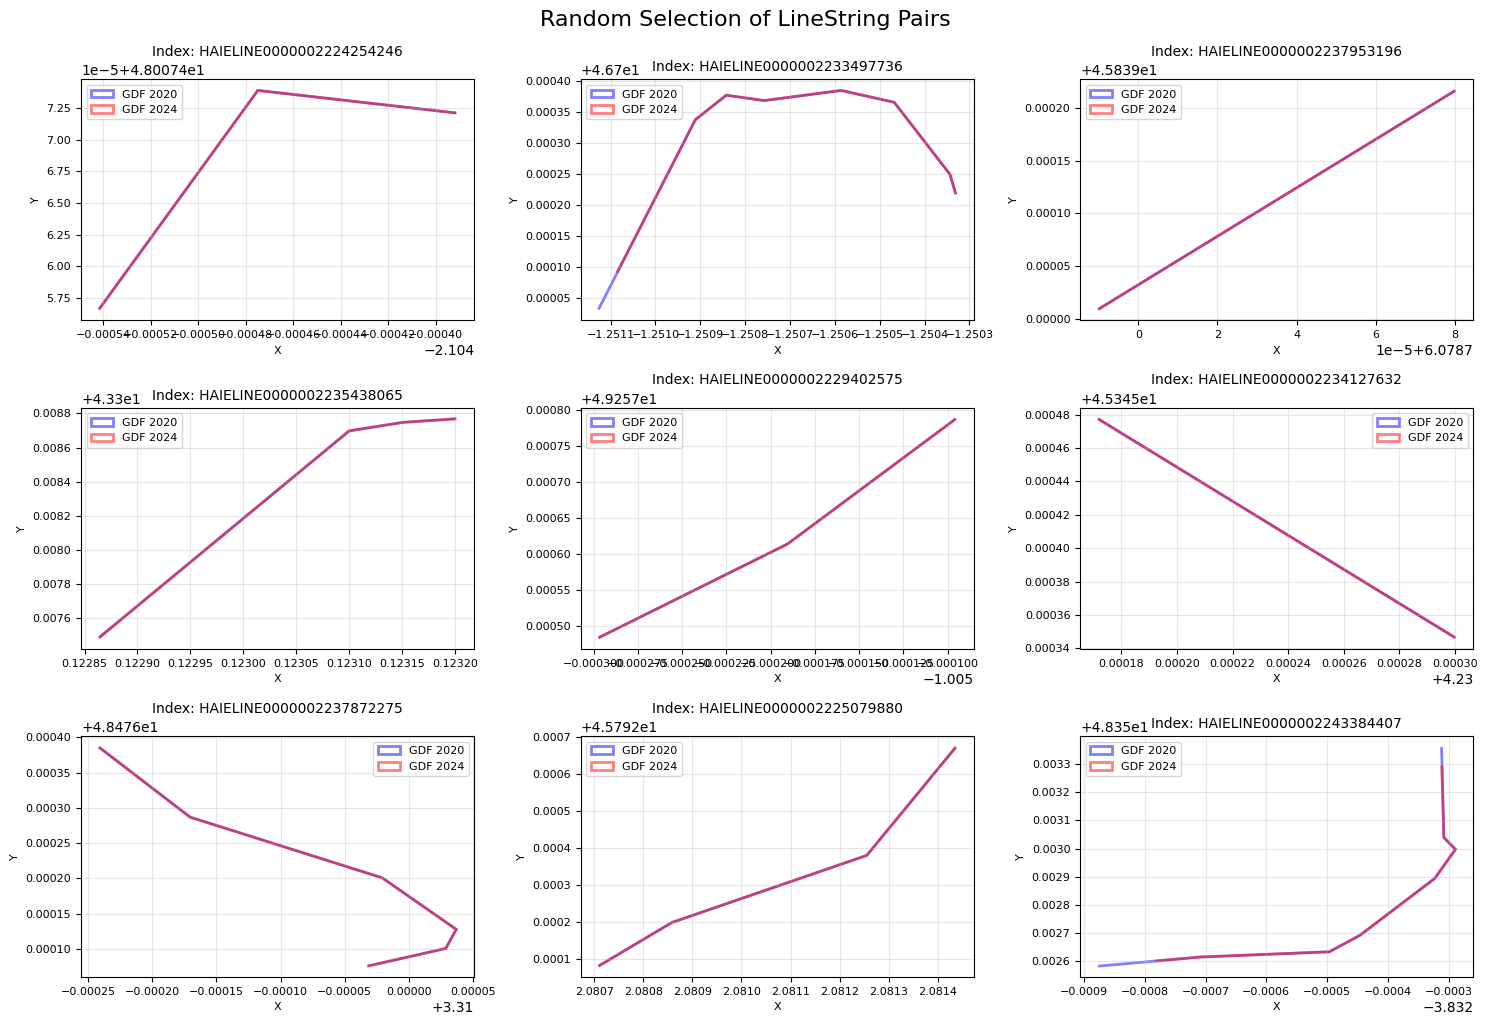

In [30]:

from typing import Tuple
from shapely.plotting import plot_line


def plot_random_linestring_pairs(gdf_2020: gpd.GeoDataFrame, gdf_2024: gpd.GeoDataFrame, 
                                 figsize: Tuple[int, int] = (15, 10), 
                                 random_state: int = None) -> None:
    
    # Validate inputs
    if not isinstance(gdf_2020, gpd.GeoDataFrame) or not isinstance(gdf_2024, gpd.GeoDataFrame):
        raise TypeError("Both inputs must be GeoDataFrames")
    
    if len(gdf_2020) == 0 or len(gdf_2024) == 0:
        raise ValueError("GeoDataFrames cannot be empty")
    
    # Check for LineString geometries (basic check on first few rows)
    sample_size = min(5, len(gdf_2020), len(gdf_2024))
    for i in range(sample_size):
        if gdf_2020.iloc[i].geometry.geom_type != 'LineString':
            print(f"Warning: gdf1 row {i} is not a LineString ({gdf_2020.iloc[i].geometry.geom_type})")
        if gdf_2024.iloc[i].geometry.geom_type != 'LineString':
            print(f"Warning: gdf2 row {i} is not a LineString ({gdf_2024.iloc[i].geometry.geom_type})")
    
    common_indices = gdf_2020["cleabs"][gdf_2020["cleabs"].isin(gdf_2024["cleabs"])] 
    
    if len(common_indices) == 0:
        raise ValueError("No common indices found between the two GeoDataFrames")
    
    if len(common_indices) < 9:
        print(f"Warning: Only {len(common_indices)} common indices available, using all of them")
        selected_indices = common_indices
    else:
        # Randomly select 9 indices
        if random_state is not None:
            np.random.seed(random_state)
        selected_indices = np.random.choice(common_indices, size=9, replace=False)
    n_plots = len(selected_indices)
    rows = int(np.ceil(n_plots / 3))
    _, axes = plt.subplots(rows, 3, figsize=figsize)
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    axes_flat = axes.flatten()
    
    for i, idx in enumerate(selected_indices):
        ax = axes_flat[i]
        
        gdf1_line = gdf_2020[gdf_2020["cleabs"] == idx].iloc[0].geometry
        gdf2_line = gdf_2024[gdf_2024["cleabs"] == idx].iloc[0].geometry
        plot_line(gdf1_line, ax=ax, color='blue', linewidth=2, label='GDF 2020', alpha=0.5, add_points=False)
        plot_line(gdf2_line, ax=ax, color='red', linewidth=2, label='GDF 2024', alpha=0.5, add_points=False)
        
        ax.set_title(f'Index: {idx}', fontsize=10)
        ax.set_xlabel('X', fontsize=8)
        ax.set_ylabel('Y', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Make axis labels smaller
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for i in range(len(selected_indices), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Random Selection of LineString Pairs', fontsize=16, y=1.02)
    plt.show()

plot_random_linestring_pairs(gdf_2020, gdf_2024)

In [34]:
missing_hedgerows.to_file("gpkgs/2020_hedgerows_absent_from_2024.gpkg", driver="GPKG")

In [ ]:
joined[]
joined.to_file("gpkgs/joined_hedgerows.gpkg", driver="GPKG")

ValueError: GeoDataFrame contains multiple geometry columns but GeoDataFrame.to_file supports only a single geometry column. Use a GeoDataFrame.to_parquet or GeoDataFrame.to_feather, drop additional geometry columns or convert them to a supported format like a well-known text (WKT) using `GeoSeries.to_wkt()`.